<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/BasicML/BasicML/Market_Direction_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [ ]:
# --- 1. DATA LOADING ---
ticker = 'SPY'
df = yf.download(ticker, start='2015-01-01', end='2024-01-01', progress=False)

# Clean structure
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

/tmp/ipython-input-2797234769.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2015-01-01', end='2024-01-01', progress=False)


In [ ]:
# --- 2. TARGET GENERATION (The "Up/Down" Logic) ---
# Calculate Next Day's Return
df['Next_Ret'] = np.log(df['Close'] / df['Close'].shift(1)).shift(-1)

# Create Binary Target: 1 if Return > 0, else 0
df['Target'] = np.where(df['Next_Ret'] > 0, 1, 0)

In [ ]:
# --- 3. FEATURE ENGINEERING ---
# Momentum
df['Ret_1d'] = df['Close'].pct_change()
df['Ret_5d'] = df['Close'].pct_change(5)

# Volatility (Standard Deviation)
df['Vol_20'] = df['Ret_1d'].rolling(20).std()

# Moving Average Trend
df['MA_20'] = df['Close'].rolling(20).mean()
df['Dist_MA_20'] = (df['Close'] - df['MA_20']) / df['MA_20']

df.dropna(inplace=True)

In [ ]:
# --- 4. TRAIN/TEST SPLIT ---
X = df[['Ret_1d', 'Ret_5d', 'Vol_20', 'Dist_MA_20']]
y = df['Target']

split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Scale Features (Logistic Regression assumes standardized inputs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# --- 5. MODELING ---
# penalty='none' or 'l2' (Ridge) is standard
model = LogisticRegression(class_weight='balanced')
# 'balanced' forces the model to pay attention to Down days even if Up days are more common
model.fit(X_train_scaled, y_train)

# Predictions
pred_test = model.predict(X_test_scaled)

Directional Accuracy: 50.78%


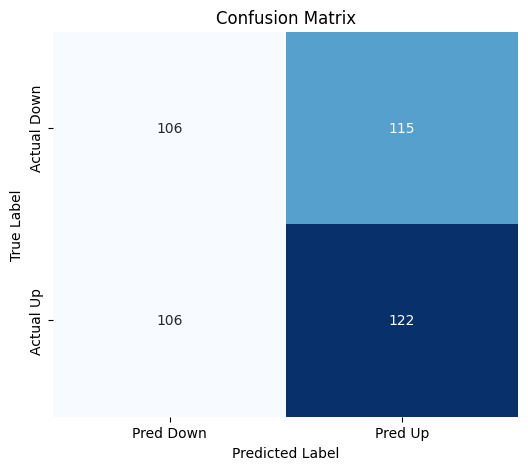


Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.48      0.49       221
           1       0.51      0.54      0.52       228

    accuracy                           0.51       449
   macro avg       0.51      0.51      0.51       449
weighted avg       0.51      0.51      0.51       449



In [ ]:
# --- 6. EVALUATION ---
acc = accuracy_score(y_test, pred_test)
print(f"Directional Accuracy: {acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Down', 'Pred Up'],
            yticklabels=['Actual Down', 'Actual Up'])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, pred_test))

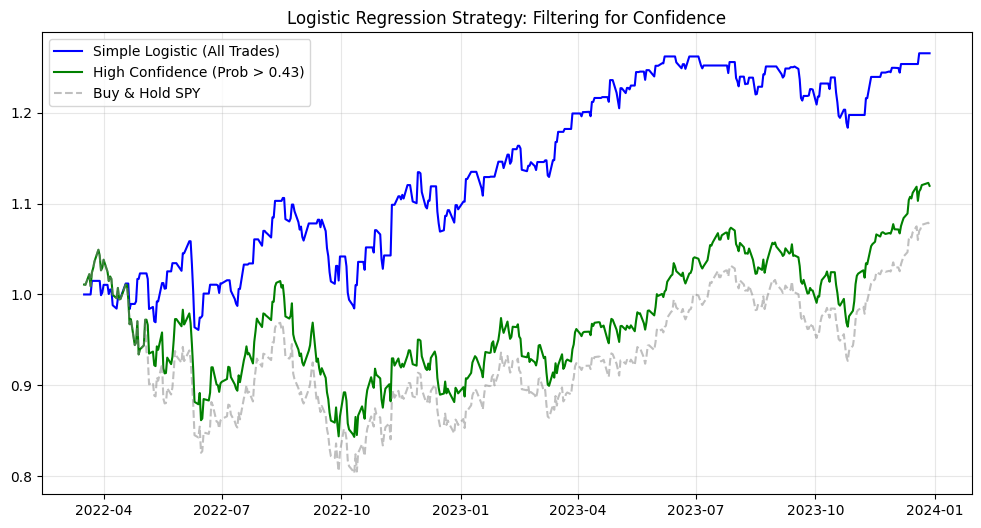

In [ ]:
# Get Probabilities (Probability of Class 1 aka "Up")
probs = model.predict_proba(X_test_scaled)[:, 1]

# Create a DataFrame for backtesting
test_df = df.iloc[split:].copy()
test_df['Prob_Up'] = probs
test_df['Prediction'] = pred_test

# --- STRATEGY LOGIC ---
# Strategy 1: Always trade the prediction (Long if Pred=1, Short/Cash if Pred=0)
test_df['Strat_Simple'] = np.where(test_df['Prediction'] == 1,
                                   test_df['Next_Ret'], 0) # 0 means we go to Cash

# Strategy 2: High Confidence Only (Threshold > 0.55)
threshold = 0.43  # Slight edge requirement
test_df['Signal_Conf'] = np.where(test_df['Prob_Up'] > threshold, 1, 0)
test_df['Strat_Conf'] = test_df['Signal_Conf'] * test_df['Next_Ret']

# Plotting
cumulative_simple = (1 + test_df['Strat_Simple']).cumprod()
cumulative_conf = (1 + test_df['Strat_Conf']).cumprod()
benchmark = (1 + test_df['Next_Ret']).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cumulative_simple, label='Simple Logistic (All Trades)', color='blue')
plt.plot(cumulative_conf, label=f'High Confidence (Prob > {threshold})', color='green')
plt.plot(benchmark, label='Buy & Hold SPY', color='gray', linestyle='--', alpha=0.5)

plt.title("Logistic Regression Strategy: Filtering for Confidence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Optimal Threshold (Max F1): 0.4306
Precision at Optimal:       51.24%
Recall at Optimal:          99.56%


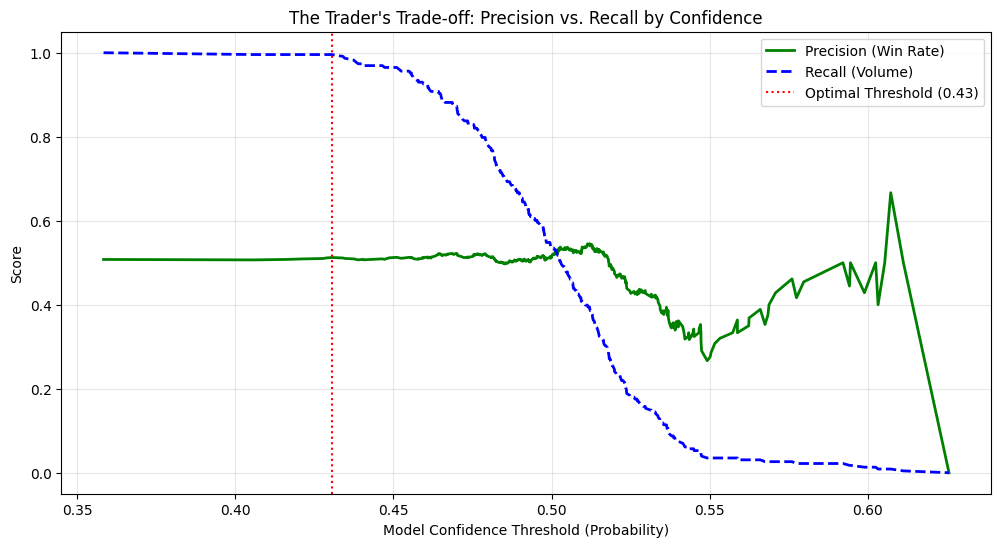

In [ ]:
from sklearn.metrics import precision_recall_curve

# --- 1. GET PROBABILITIES ---
# model.predict_proba returns [Prob_Down, Prob_Up]. We want column 1.
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# --- 2. CALCULATE PRECISION-RECALL CURVE ---
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# --- 3. FIND THE "SWEET SPOT" (Max F1 Score) ---
# F1 = Harmonic Mean of Precision and Recall
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)  # +1e-10 avoids div by zero
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]

print(f"Optimal Threshold (Max F1): {best_thresh:.4f}")
print(f"Precision at Optimal:       {best_precision:.2%}")
print(f"Recall at Optimal:          {best_recall:.2%}")

# --- 4. VISUALIZATION ---
plt.figure(figsize=(12, 6))

# Plot Precision (Win Rate)
# Note: thresholds array is 1 element shorter than precision array, so we slice precision[:-1]
plt.plot(thresholds, precision[:-1], label='Precision (Win Rate)', color='green', linewidth=2)

# Plot Recall (Opportunity Capture)
plt.plot(thresholds, recall[:-1], label='Recall (Volume)', color='blue', linewidth=2, linestyle='--')

# Mark the Optimal Threshold
plt.axvline(best_thresh, color='red', linestyle=':', label=f'Optimal Threshold ({best_thresh:.2f})')

plt.title("The Trader's Trade-off: Precision vs. Recall by Confidence")
plt.xlabel("Model Confidence Threshold (Probability)")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()